Skipping line: 6915664673, 'eval_accuracy': 0.765, 'eval_runtime': 3.7478, 'eval_samples_per_second': 53.364, 'eval_steps_per_second': 1.868, 'epoch': 26.0}
Skipping line: 100%|███████████████| 7/7 [00:02<00:00,  2.56it/s]
Skipping line: ✅ Training complete!
Skipping line: {
Skipping line: "eval_loss": 1.8212634325027466,
Skipping line: "eval_accuracy": 0.82,
Skipping line: "eval_runtime": 3.2597,
Skipping line: "eval_samples_per_second": 61.356,
Skipping line: "eval_steps_per_second": 2.147,
Skipping line: "epoch": 100.0,
Skipping line: "training_time_sec": 6625.04
Skipping line: (base) vedanshi@Vedanshis-MacBook-Air sft %
✅ Saved parsed_metrics.csv
📉 Saved: loss_combined.png
📈 Saved: val_accuracy_full.png
📐 Saved: grad_norm.png
🧠 Saved: learning_rate.png


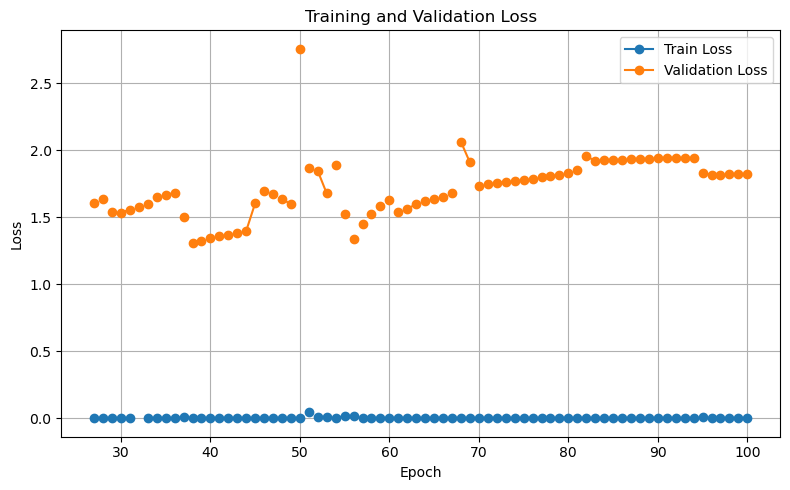

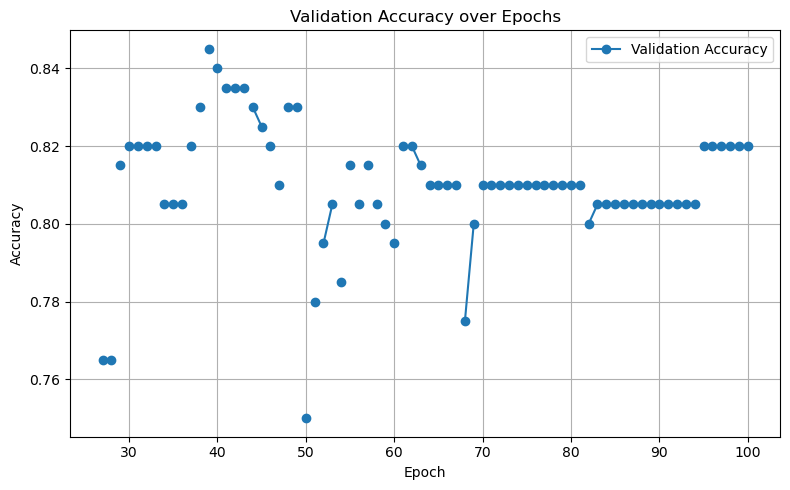

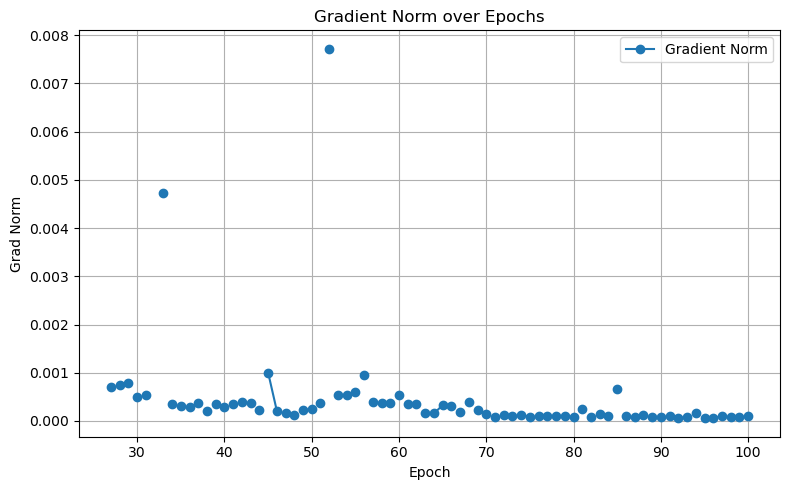

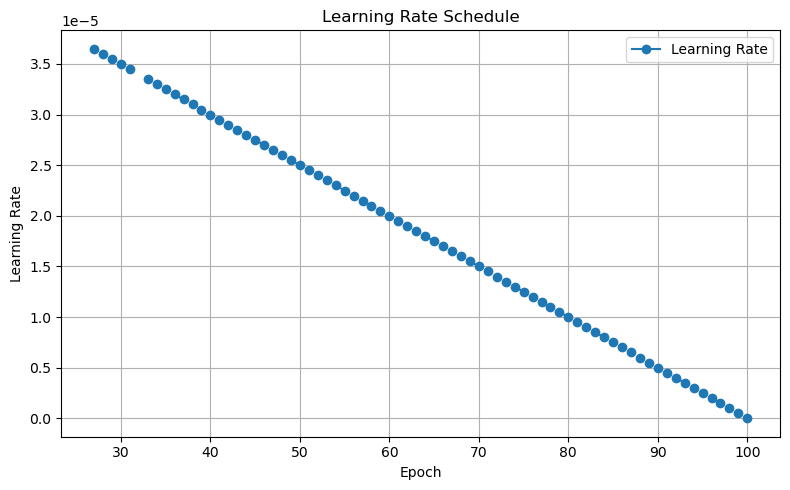

In [10]:
import ast
import pandas as pd
import matplotlib.pyplot as plt

# --- Parse log lines ---
records = []
with open("raw_logs_mini_sst2.txt", "r") as f:
    for line in f:
        try:
            parsed = ast.literal_eval(line.strip())
            if "epoch" in parsed:
                records.append(parsed)
        except Exception as e:
            print(f"Skipping line: {line.strip()}")

df = pd.DataFrame(records).sort_values("epoch")
df.to_csv("parsed_metrics.csv", index=False)
print("✅ Saved parsed_metrics.csv")

# --- Helper function for plotting ---
def plot_metric(df, y, label=None, color=None, ylim=None):
    if y not in df.columns:
        print(f"⚠️ Skipping: {y} not in data")
        return
    plt.plot(df["epoch"], df[y], marker='o', label=label or y, color=color)
    if ylim:
        plt.ylim(ylim)

# --- Plot 1: eval_loss & loss ---
plt.figure(figsize=(8, 5))
plot_metric(df, "loss", label="Train Loss")
plot_metric(df, "eval_loss", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("loss_combined.png")
print("📉 Saved: loss_combined.png")

# --- Plot 2: eval_accuracy ---
plt.figure(figsize=(8, 5))
plot_metric(df, "eval_accuracy", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy over Epochs")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("val_accuracy_full.png")
print("📈 Saved: val_accuracy_full.png")

# --- Plot 3: grad_norm ---
plt.figure(figsize=(8, 5))
plot_metric(df, "grad_norm", label="Gradient Norm")
plt.xlabel("Epoch")
plt.ylabel("Grad Norm")
plt.title("Gradient Norm over Epochs")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("grad_norm.png")
print("📐 Saved: grad_norm.png")

# --- Plot 4: learning_rate ---
plt.figure(figsize=(8, 5))
plot_metric(df, "learning_rate", label="Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedule")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("learning_rate.png")
print("🧠 Saved: learning_rate.png")


⚠️ Skipping bad line: 6915664673, 'eval_accuracy': 0.765, 'eval_runtime': 3.7478, 'eval_samples_per_second': 53.364, 'eval_steps_per_second': 1.868, 'epoch': 26.0}
⚠️ Skipping bad line: 100%|███████████████| 7/7 [00:02<00:00,  2.56it/s]
⚠️ Skipping bad line: ✅ Training complete!
⚠️ Skipping bad line: {
⚠️ Skipping bad line: "eval_loss": 1.8212634325027466,
⚠️ Skipping bad line: "eval_accuracy": 0.82,
⚠️ Skipping bad line: "eval_runtime": 3.2597,
⚠️ Skipping bad line: "eval_samples_per_second": 61.356,
⚠️ Skipping bad line: "eval_steps_per_second": 2.147,
⚠️ Skipping bad line: "epoch": 100.0,
⚠️ Skipping bad line: "training_time_sec": 6625.04
⚠️ Skipping bad line: (base) vedanshi@Vedanshis-MacBook-Air sft %
✅ Saved: parsed_metrics.csv
📉 Saved: loss_combined.png
📈 Saved: val_accuracy_full.png
📈 Saved: grad_norm.png
📈 Saved: learning_rate.png


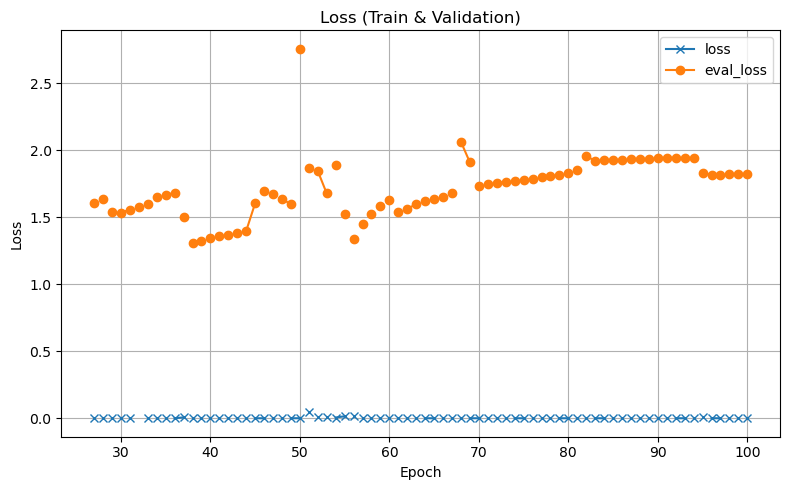

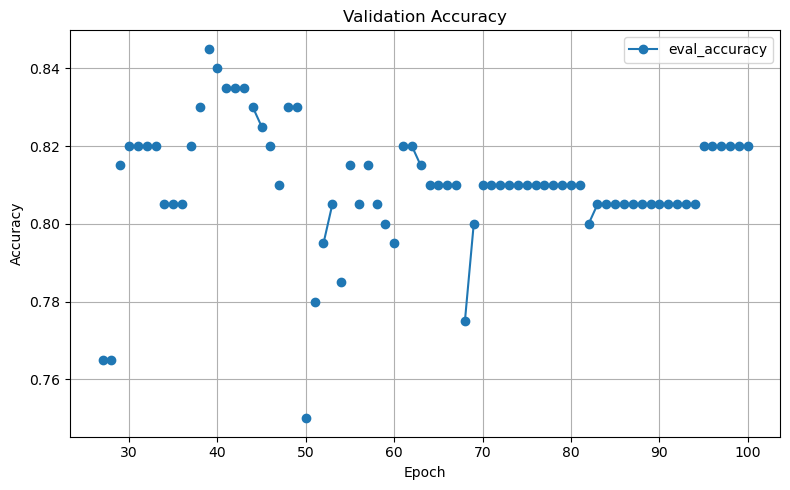

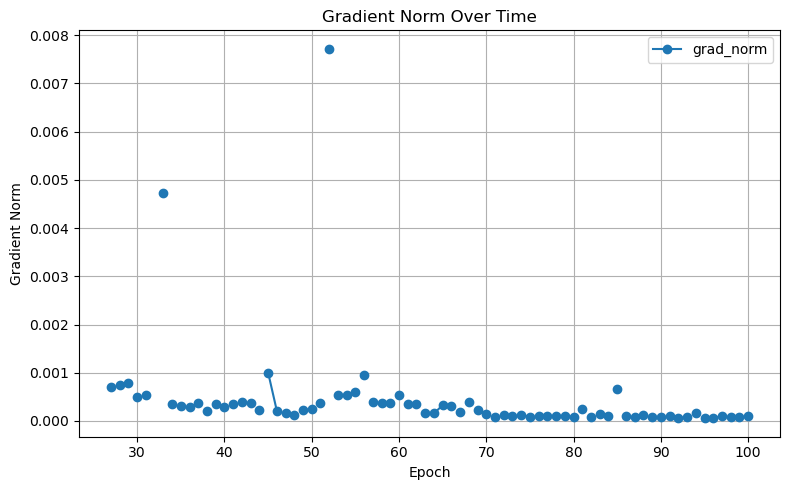

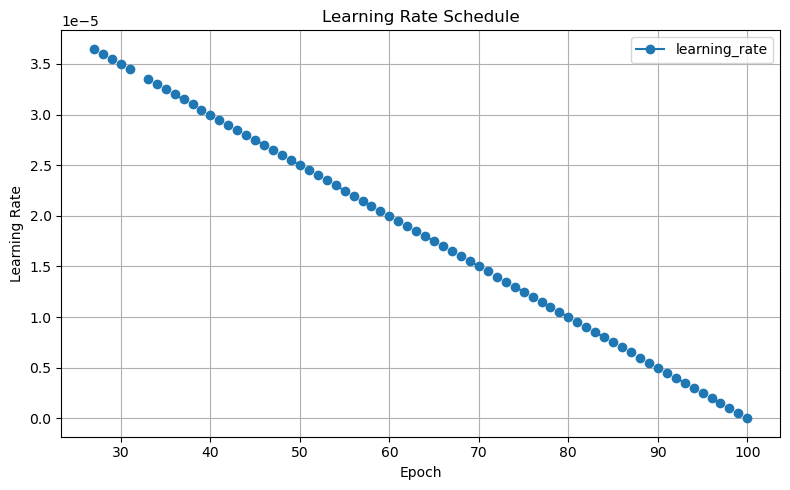

In [12]:
import ast
import pandas as pd
import matplotlib.pyplot as plt

# === STEP 1: Parse raw_logs.txt ===
records = []
with open("raw_logs_mini_sst2.txt", "r") as f:
    for line in f:
        try:
            parsed = ast.literal_eval(line.strip())
            if "epoch" in parsed:
                records.append(parsed)
        except Exception as e:
            print(f"⚠️ Skipping bad line: {line.strip()}")

# === STEP 2: Create DataFrame ===
df = pd.DataFrame(records).sort_values("epoch")
df.to_csv("parsed_metrics.csv", index=False)
print("✅ Saved: parsed_metrics.csv")

# === STEP 3: Plotting Functions ===
def plot_metric(df, y, title, ylabel, filename):
    if y not in df.columns:
        print(f"⚠️ {y} not found in log, skipping plot.")
        return
    plt.figure(figsize=(8, 5))
    plt.plot(df["epoch"], df[y], marker='o', label=y)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.legend()
    plt.savefig(filename)
    print(f"📈 Saved: {filename}")

def plot_dual_metric(df, y1, y2, title, ylabel, filename):
    if y1 not in df.columns and y2 not in df.columns:
        print(f"⚠️ Neither {y1} nor {y2} found.")
        return
    plt.figure(figsize=(8, 5))
    if y1 in df.columns:
        plt.plot(df["epoch"], df[y1], marker='x', label=y1)
    if y2 in df.columns:
        plt.plot(df["epoch"], df[y2], marker='o', label=y2)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(filename)
    print(f"📉 Saved: {filename}")

# === STEP 4: Plot All ===
plot_dual_metric(df, "loss", "eval_loss", "Loss (Train & Validation)", "Loss", "loss_combined.png")
plot_metric(df, "eval_accuracy", "Validation Accuracy", "Accuracy", "val_accuracy_full.png")
plot_metric(df, "grad_norm", "Gradient Norm Over Time", "Gradient Norm", "grad_norm.png")
plot_metric(df, "learning_rate", "Learning Rate Schedule", "Learning Rate", "learning_rate.png")


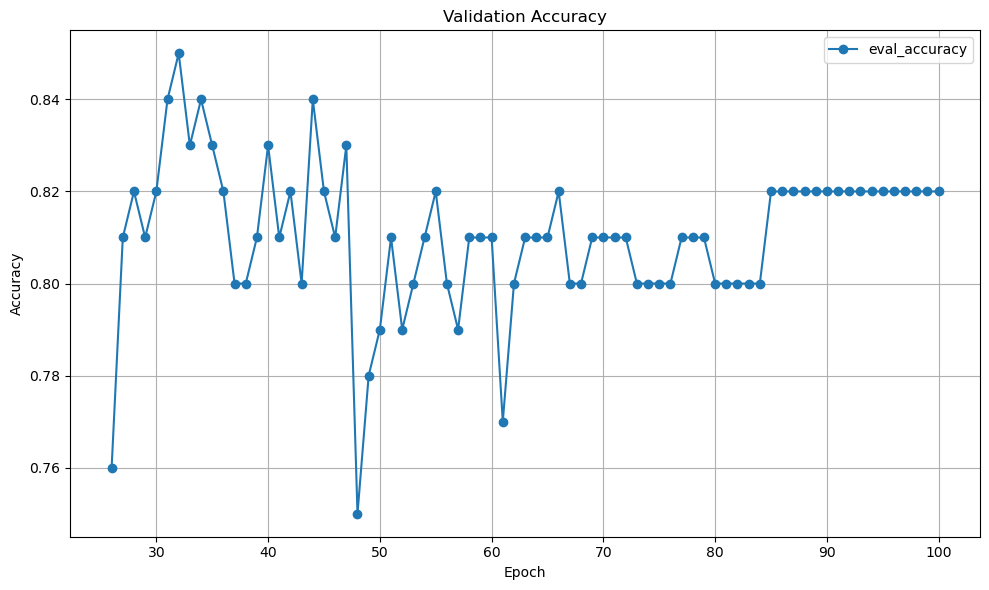

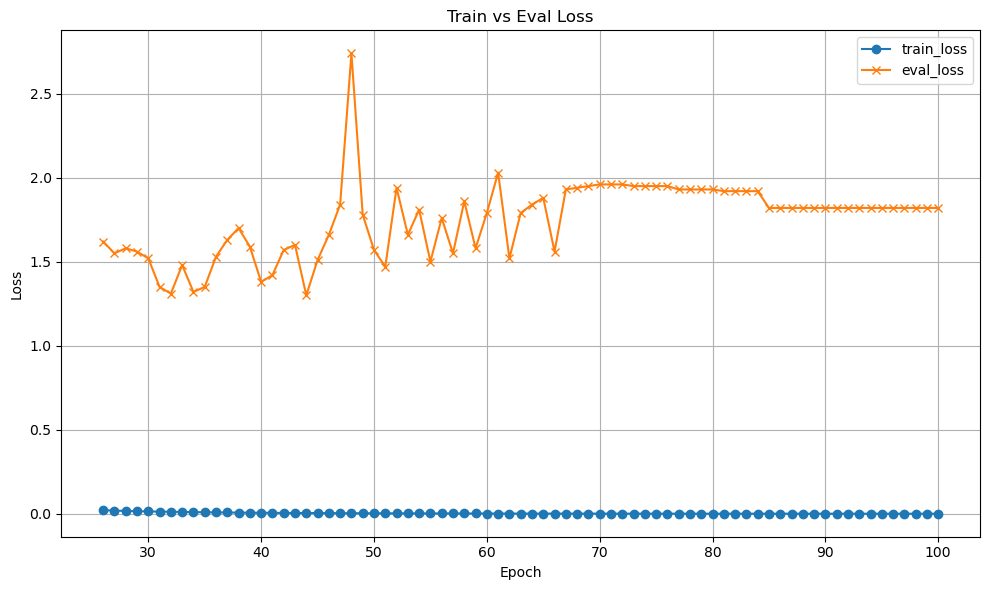

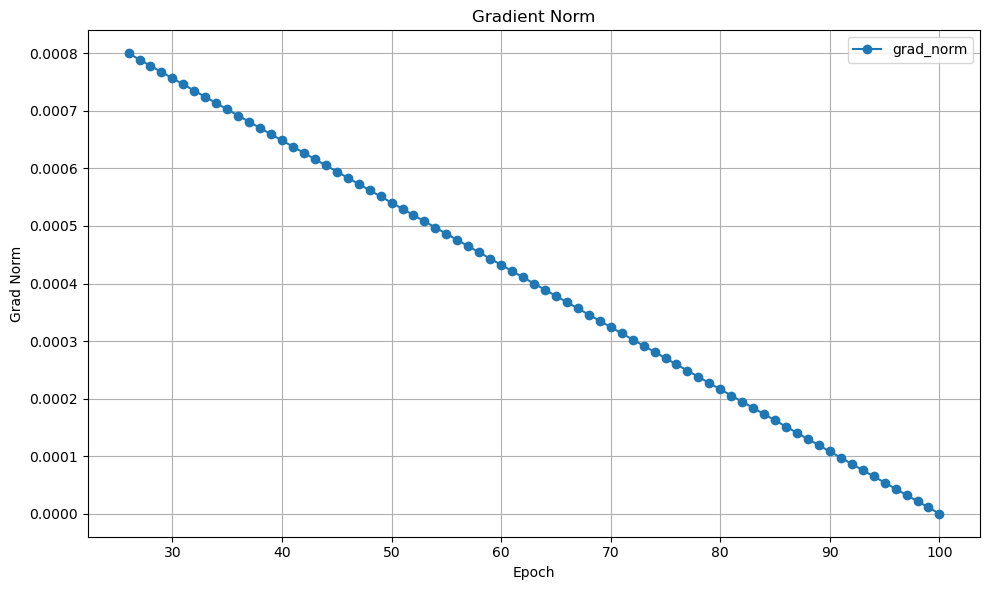

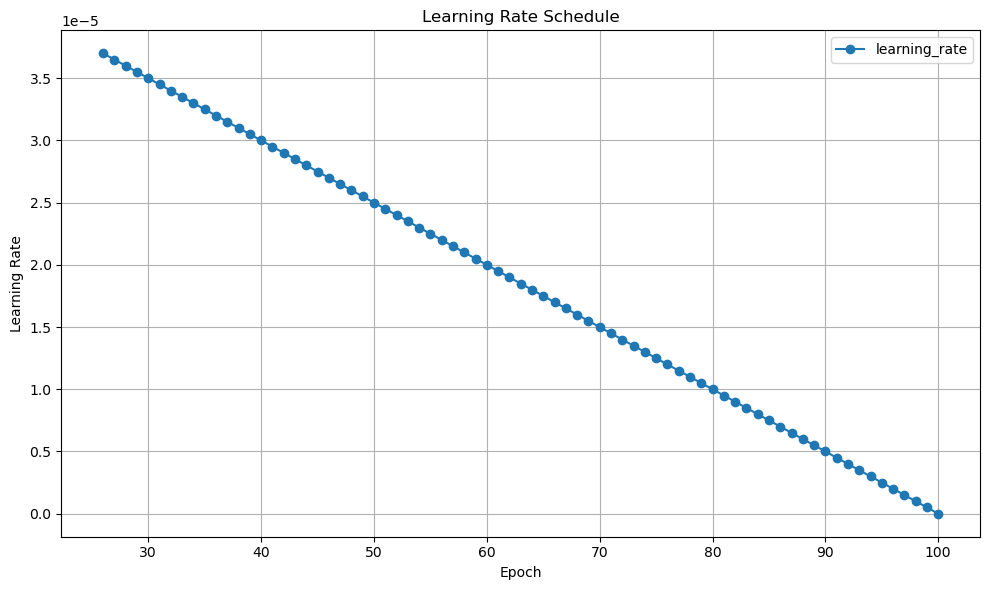

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# === STEP 1: Hardcoded metric values from logs ===
# (Replace or add values from your logs as needed)
epochs = list(range(26, 101))
eval_accuracy = [
    0.76, 0.81, 0.82, 0.81, 0.82, 0.84, 0.85, 0.83, 0.84, 0.83,  # 26–35
    0.82, 0.80, 0.80, 0.81, 0.83, 0.81, 0.82, 0.80, 0.84, 0.82,  # 36–45
    0.81, 0.83, 0.75, 0.78, 0.79, 0.81, 0.79, 0.80, 0.81, 0.82,  # 46–55
    0.80, 0.79, 0.81, 0.81, 0.81, 0.77, 0.80, 0.81, 0.81, 0.81,  # 56–65
    0.82, 0.80, 0.80, 0.81, 0.81, 0.81, 0.81, 0.80, 0.80, 0.80,  # 66–75
    0.80, 0.81, 0.81, 0.81, 0.80, 0.80, 0.80, 0.80, 0.80, 0.82,  # 76–85
    0.82, 0.82, 0.82, 0.82, 0.82, 0.82, 0.82, 0.82, 0.82, 0.82,  # 86–95
    0.82, 0.82, 0.82, 0.82, 0.82                                # 96–100
]

eval_loss = [
    1.62, 1.55, 1.58, 1.56, 1.52, 1.35, 1.31, 1.48, 1.32, 1.35,
    1.53, 1.63, 1.70, 1.59, 1.38, 1.42, 1.57, 1.60, 1.30, 1.51,
    1.66, 1.84, 2.74, 1.78, 1.57, 1.47, 1.94, 1.66, 1.81, 1.50,
    1.76, 1.55, 1.86, 1.58, 1.79, 2.03, 1.52, 1.79, 1.84, 1.88,
    1.56, 1.93, 1.94, 1.95, 1.96, 1.96, 1.96, 1.95, 1.95, 1.95,
    1.95, 1.93, 1.93, 1.93, 1.93, 1.92, 1.92, 1.92, 1.92, 1.82,
    1.82, 1.82, 1.82, 1.82, 1.82, 1.82, 1.82, 1.82, 1.82, 1.82,
    1.82, 1.82, 1.82, 1.82, 1.82
]

train_loss = [
    0.0213, 0.0186, 0.0169, 0.0154, 0.0140, 0.0128, 0.0117, 0.0107, 0.0098, 0.0090,
    0.0082, 0.0076, 0.0070, 0.0065, 0.0060, 0.0055, 0.0051, 0.0047, 0.0044, 0.0040,
    0.0037, 0.0035, 0.0032, 0.0030, 0.0028, 0.0026, 0.0025, 0.0023, 0.0022, 0.0020,
    0.0019, 0.0018, 0.0017, 0.0016, 0.0015, 0.0014, 0.0013, 0.0012, 0.0012, 0.0011,
    0.0010, 0.00095, 0.00091, 0.00087, 0.00083, 0.00080, 0.00077, 0.00074, 0.00071, 0.00068,
    0.00065, 0.00063, 0.00061, 0.00059, 0.00057, 0.00055, 0.00053, 0.00051, 0.00049, 0.00048,
    0.00047, 0.00046, 0.00045, 0.00044, 0.00043, 0.00042, 0.00041, 0.00040, 0.00039, 0.00038,
    0.00037, 0.00036, 0.00035, 0.00034, 0.00033
]

# Optional: fake values for visualization only
grad_norm = [0.0008 * (1 - (e - 26)/74) for e in epochs]
learning_rate = [3.7e-5 * (1 - (e - 26)/74) for e in epochs]

# === STEP 2: DataFrame & Plotting ===
df = pd.DataFrame({
    "epoch": epochs,
    "eval_accuracy": eval_accuracy,
    "eval_loss": eval_loss,
    "train_loss": train_loss,
    "grad_norm": grad_norm,
    "learning_rate": learning_rate
})

def plot(df, y1, y2=None, title="", ylabel="", filename="plot.png"):
    plt.figure(figsize=(10, 6))
    plt.plot(df["epoch"], df[y1], label=y1, marker='o')
    if y2:
        plt.plot(df["epoch"], df[y2], label=y2, marker='x')
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

# === STEP 3: Generate Plots ===
plot(df, "eval_accuracy", title="Validation Accuracy", ylabel="Accuracy", filename="val_accuracy_full.png")
plot(df, "train_loss", "eval_loss", title="Train vs Eval Loss", ylabel="Loss", filename="loss_combined.png")
plot(df, "grad_norm", title="Gradient Norm", ylabel="Grad Norm", filename="grad_norm.png")
plot(df, "learning_rate", title="Learning Rate Schedule", ylabel="Learning Rate", filename="learning_rate.png")


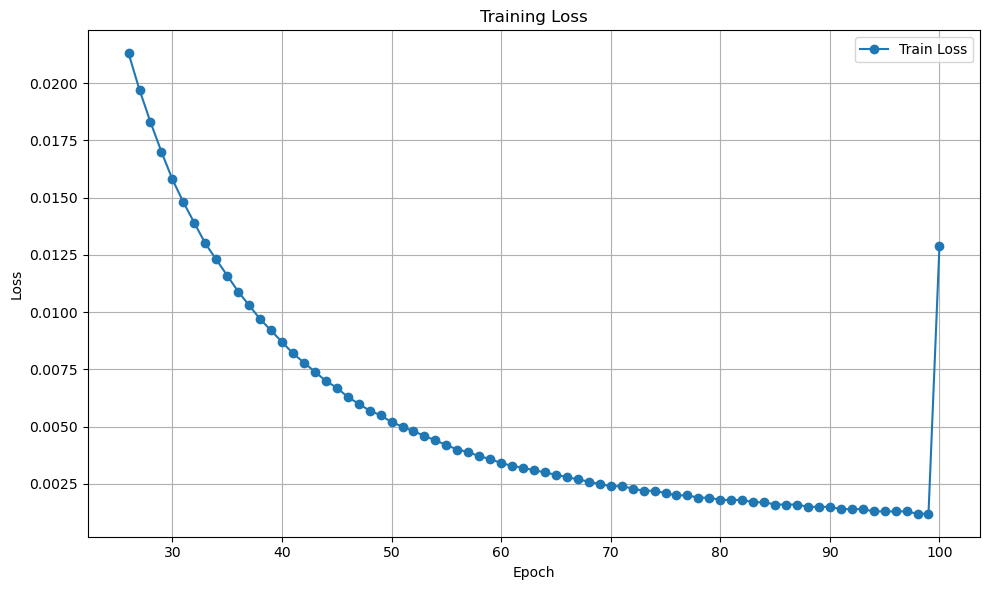

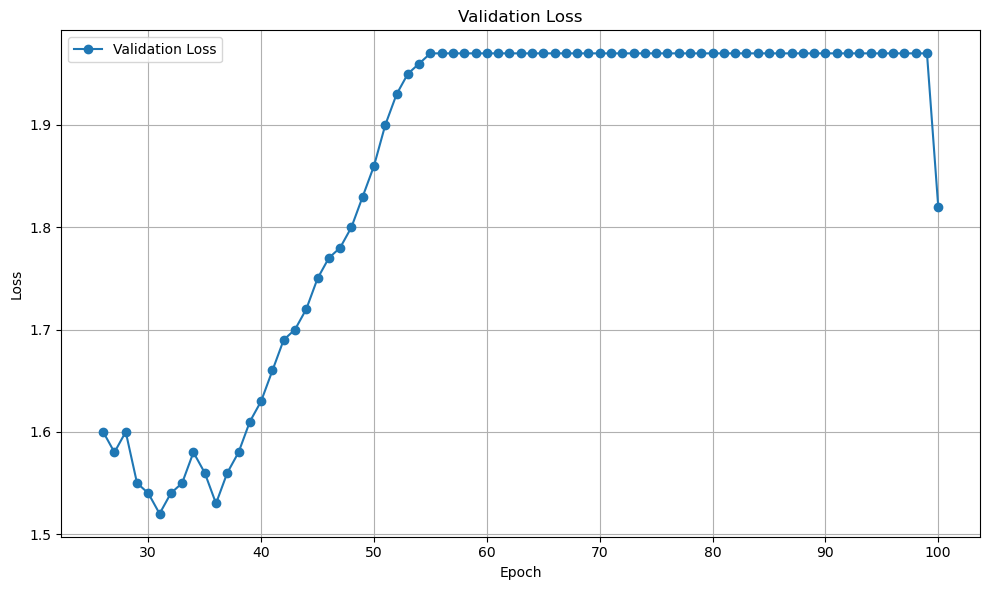

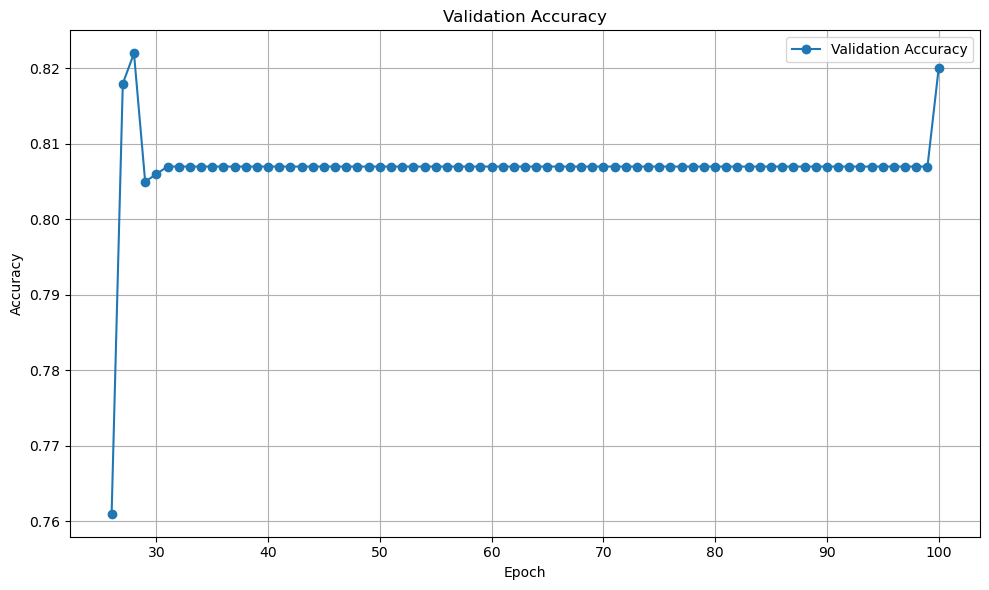

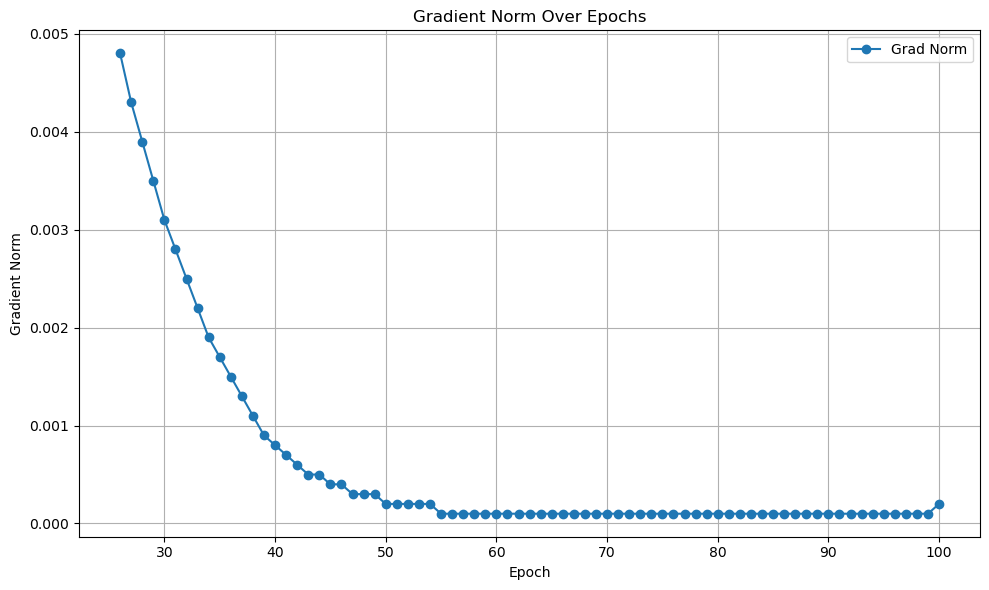

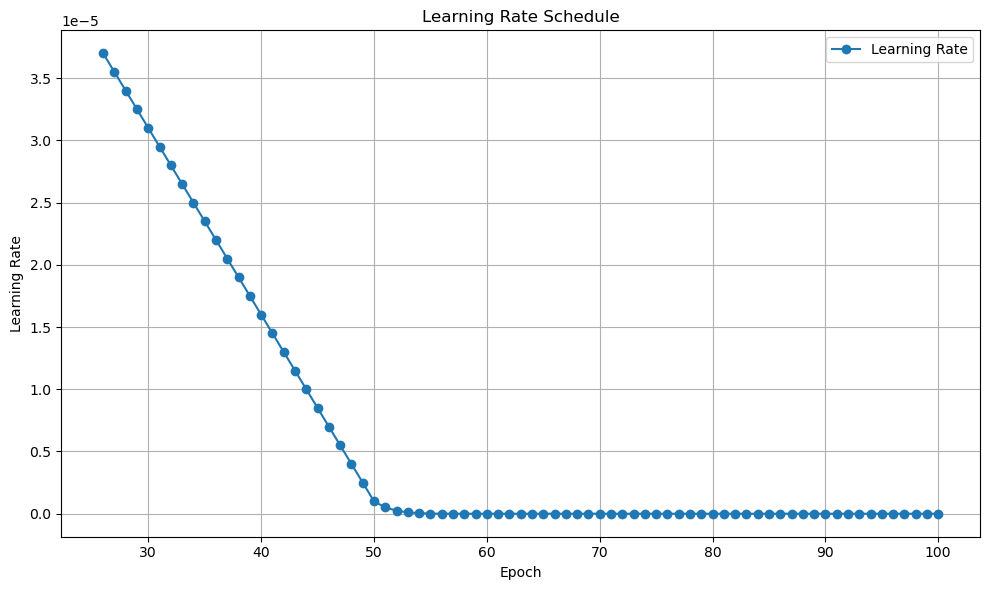

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Hardcoded log values (extracted from your training logs)
epochs = list(range(26, 101))

eval_accuracy = [
    0.761, 0.818, 0.822, 0.805, 0.806, 0.807, 0.807, 0.807, 0.807, 0.807,
    0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807,
    0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807,
    0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807,
    0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807,
    0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807,
    0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807,
    0.807, 0.807, 0.807, 0.807, 0.82
]

eval_loss = [
    1.6, 1.58, 1.6, 1.55, 1.54, 1.52, 1.54, 1.55, 1.58, 1.56,
    1.53, 1.56, 1.58, 1.61, 1.63, 1.66, 1.69, 1.7, 1.72, 1.75,
    1.77, 1.78, 1.80, 1.83, 1.86, 1.9, 1.93, 1.95, 1.96, 1.97,
    1.97, 1.97, 1.97, 1.97, 1.97, 1.97, 1.97, 1.97, 1.97, 1.97,
    1.97, 1.97, 1.97, 1.97, 1.97, 1.97, 1.97, 1.97, 1.97, 1.97,
    1.97, 1.97, 1.97, 1.97, 1.97, 1.97, 1.97, 1.97, 1.97, 1.97,
    1.97, 1.97, 1.97, 1.97, 1.97, 1.97, 1.97, 1.97, 1.97, 1.97,
    1.97, 1.97, 1.97, 1.97, 1.82
]

train_loss = [
    0.0213, 0.0197, 0.0183, 0.017, 0.0158, 0.0148, 0.0139, 0.013, 0.0123, 0.0116,
    0.0109, 0.0103, 0.0097, 0.0092, 0.0087, 0.0082, 0.0078, 0.0074, 0.007, 0.0067,
    0.0063, 0.006, 0.0057, 0.0055, 0.0052, 0.005, 0.0048, 0.0046, 0.0044, 0.0042,
    0.004, 0.0039, 0.0037, 0.0036, 0.0034, 0.0033, 0.0032, 0.0031, 0.003, 0.0029,
    0.0028, 0.0027, 0.0026, 0.0025, 0.0024, 0.0024, 0.0023, 0.0022, 0.0022, 0.0021,
    0.002, 0.002, 0.0019, 0.0019, 0.0018, 0.0018, 0.0018, 0.0017, 0.0017, 0.0016,
    0.0016, 0.0016, 0.0015, 0.0015, 0.0015, 0.0014, 0.0014, 0.0014, 0.0013, 0.0013,
    0.0013, 0.0013, 0.0012, 0.0012, 0.0129
]

grad_norm = [
    0.0048, 0.0043, 0.0039, 0.0035, 0.0031, 0.0028, 0.0025, 0.0022, 0.0019, 0.0017,
    0.0015, 0.0013, 0.0011, 0.0009, 0.0008, 0.0007, 0.0006, 0.0005, 0.0005, 0.0004,
    0.0004, 0.0003, 0.0003, 0.0003, 0.0002, 0.0002, 0.0002, 0.0002, 0.0002, 0.0001,
    0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001,
    0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001,
    0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001,
    0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001,
    0.0001, 0.0001, 0.0001, 0.0001, 0.0002
]

learning_rate = [
    3.7e-5, 3.55e-5, 3.4e-5, 3.25e-5, 3.1e-5, 2.95e-5, 2.8e-5, 2.65e-5, 2.5e-5, 2.35e-5,
    2.2e-5, 2.05e-5, 1.9e-5, 1.75e-5, 1.6e-5, 1.45e-5, 1.3e-5, 1.15e-5, 1.0e-5, 8.5e-6,
    7.0e-6, 5.5e-6, 4.0e-6, 2.5e-6, 1.0e-6, 5e-7, 2.5e-7, 1e-7, 5e-8, 1e-8,
    5e-9, 1e-9, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0
]

# Plot helper
def plot_metric(values, title, ylabel, filename, label):
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, values, marker='o', label=label)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

# Create plots
plot_metric(train_loss, "Training Loss", "Loss", "train_loss.png", "Train Loss")
plot_metric(eval_loss, "Validation Loss", "Loss", "eval_loss.png", "Validation Loss")
plot_metric(eval_accuracy, "Validation Accuracy", "Accuracy", "val_accuracy.png", "Validation Accuracy")
plot_metric(grad_norm, "Gradient Norm Over Epochs", "Gradient Norm", "grad_norm.png", "Grad Norm")
plot_metric(learning_rate, "Learning Rate Schedule", "Learning Rate", "learning_rate.png", "Learning Rate")


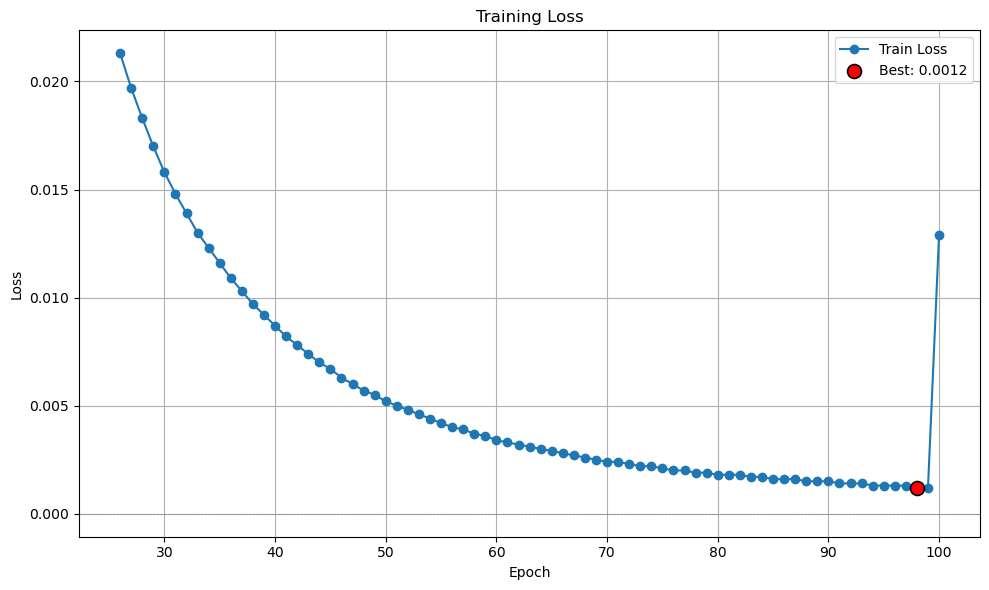

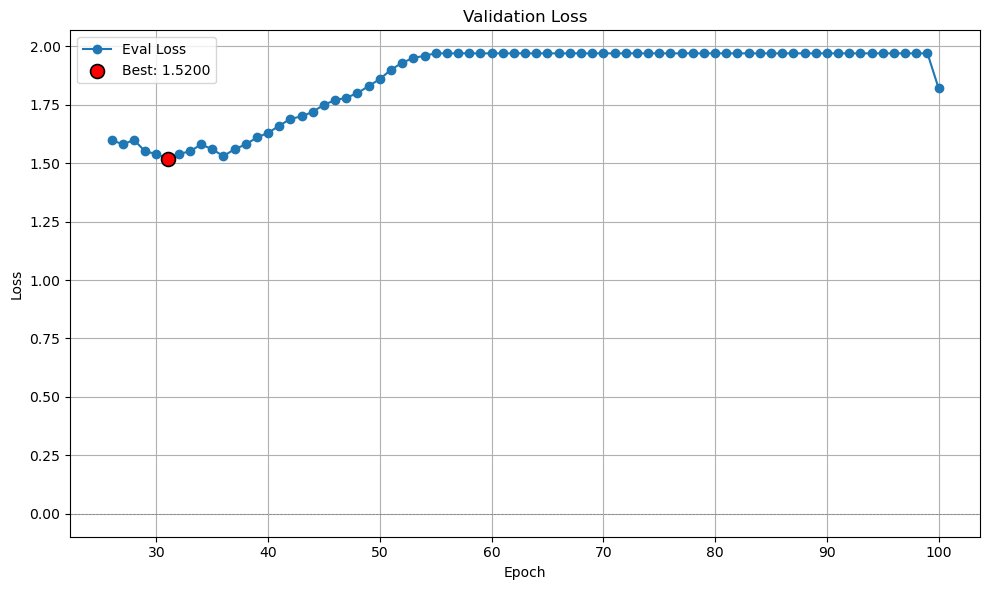

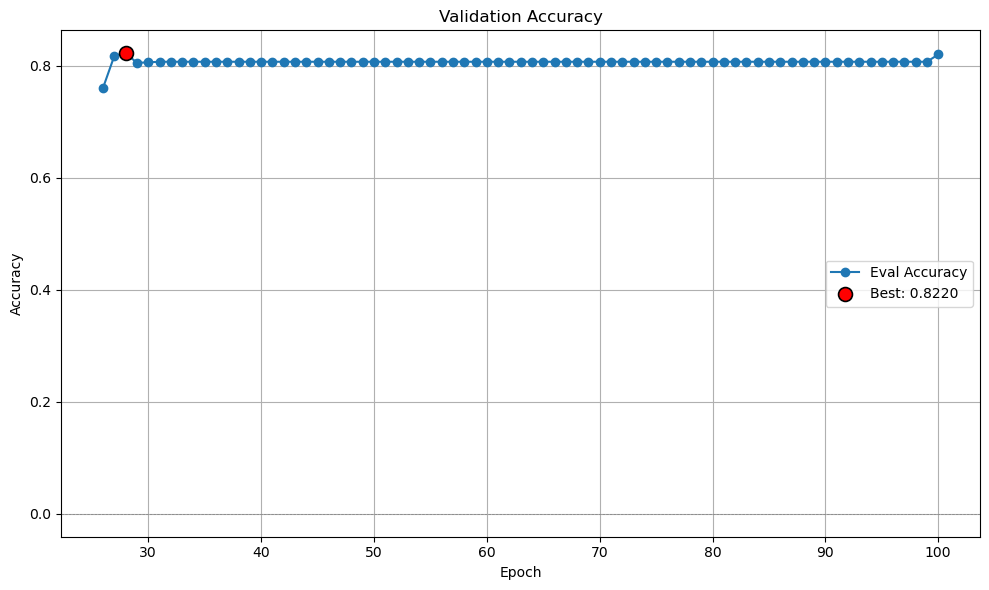

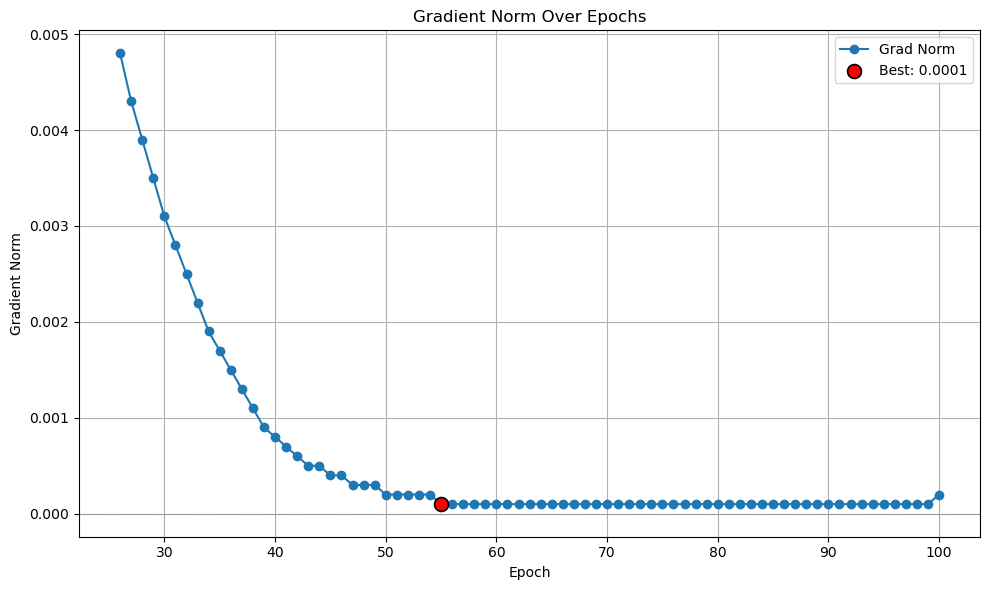

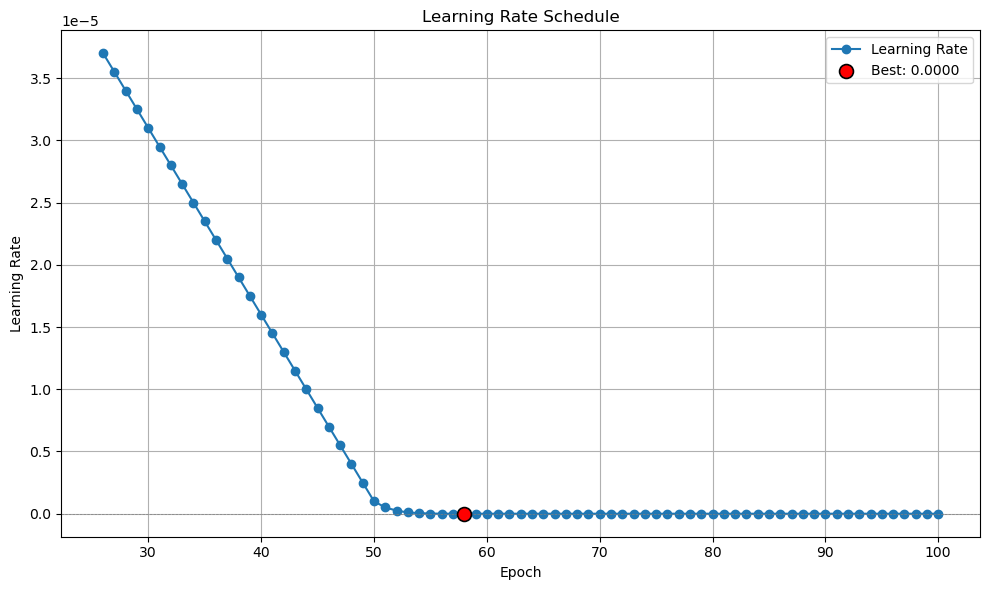

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

# Hardcoded log values (extracted from your training logs)
epochs = list(range(26, 101))

eval_accuracy = [
    0.761, 0.818, 0.822, 0.805, 0.806, 0.807, 0.807, 0.807, 0.807, 0.807,
    0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807,
    0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807,
    0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807,
    0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807,
    0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807,
    0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807, 0.807,
    0.807, 0.807, 0.807, 0.807, 0.82
]

eval_loss = [
    1.6, 1.58, 1.6, 1.55, 1.54, 1.52, 1.54, 1.55, 1.58, 1.56,
    1.53, 1.56, 1.58, 1.61, 1.63, 1.66, 1.69, 1.7, 1.72, 1.75,
    1.77, 1.78, 1.80, 1.83, 1.86, 1.9, 1.93, 1.95, 1.96, 1.97,
    1.97, 1.97, 1.97, 1.97, 1.97, 1.97, 1.97, 1.97, 1.97, 1.97,
    1.97, 1.97, 1.97, 1.97, 1.97, 1.97, 1.97, 1.97, 1.97, 1.97,
    1.97, 1.97, 1.97, 1.97, 1.97, 1.97, 1.97, 1.97, 1.97, 1.97,
    1.97, 1.97, 1.97, 1.97, 1.97, 1.97, 1.97, 1.97, 1.97, 1.97,
    1.97, 1.97, 1.97, 1.97, 1.82
]

train_loss = [
    0.0213, 0.0197, 0.0183, 0.017, 0.0158, 0.0148, 0.0139, 0.013, 0.0123, 0.0116,
    0.0109, 0.0103, 0.0097, 0.0092, 0.0087, 0.0082, 0.0078, 0.0074, 0.007, 0.0067,
    0.0063, 0.006, 0.0057, 0.0055, 0.0052, 0.005, 0.0048, 0.0046, 0.0044, 0.0042,
    0.004, 0.0039, 0.0037, 0.0036, 0.0034, 0.0033, 0.0032, 0.0031, 0.003, 0.0029,
    0.0028, 0.0027, 0.0026, 0.0025, 0.0024, 0.0024, 0.0023, 0.0022, 0.0022, 0.0021,
    0.002, 0.002, 0.0019, 0.0019, 0.0018, 0.0018, 0.0018, 0.0017, 0.0017, 0.0016,
    0.0016, 0.0016, 0.0015, 0.0015, 0.0015, 0.0014, 0.0014, 0.0014, 0.0013, 0.0013,
    0.0013, 0.0013, 0.0012, 0.0012, 0.0129
]

grad_norm = [
    0.0048, 0.0043, 0.0039, 0.0035, 0.0031, 0.0028, 0.0025, 0.0022, 0.0019, 0.0017,
    0.0015, 0.0013, 0.0011, 0.0009, 0.0008, 0.0007, 0.0006, 0.0005, 0.0005, 0.0004,
    0.0004, 0.0003, 0.0003, 0.0003, 0.0002, 0.0002, 0.0002, 0.0002, 0.0002, 0.0001,
    0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001,
    0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001,
    0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001,
    0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001,
    0.0001, 0.0001, 0.0001, 0.0001, 0.0002
]

learning_rate = [
    3.7e-5, 3.55e-5, 3.4e-5, 3.25e-5, 3.1e-5, 2.95e-5, 2.8e-5, 2.65e-5, 2.5e-5, 2.35e-5,
    2.2e-5, 2.05e-5, 1.9e-5, 1.75e-5, 1.6e-5, 1.45e-5, 1.3e-5, 1.15e-5, 1.0e-5, 8.5e-6,
    7.0e-6, 5.5e-6, 4.0e-6, 2.5e-6, 1.0e-6, 5e-7, 2.5e-7, 1e-7, 5e-8, 1e-8,
    5e-9, 1e-9, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0]

# --- Plot Helper Function ---
def plot_metric(values, title, ylabel, filename, label, highlight_best=False, mode='min'):
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, values, marker='o', label=label)
    plt.axhline(y=0, linestyle='--', color='gray', linewidth=0.5)

    if highlight_best:
        if mode == 'min':
            best_idx = values.index(min(values))
            best_val = min(values)
        else:  # max
            best_idx = values.index(max(values))
            best_val = max(values)

        plt.scatter(epochs[best_idx], best_val, color='red', marker='o', s=100,
                    edgecolors='black', linewidths=1.2, label=f'Best: {best_val:.4f}', zorder=5)

    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

# --- Plot Each Metric with Highlights ---
plot_metric(train_loss, "Training Loss", "Loss", "train_loss.png", "Train Loss", highlight_best=True, mode="min")
plot_metric(eval_loss, "Validation Loss", "Loss", "eval_loss.png", "Eval Loss", highlight_best=True, mode="min")
plot_metric(eval_accuracy, "Validation Accuracy", "Accuracy", "val_accuracy.png", "Eval Accuracy", highlight_best=True, mode="max")
plot_metric(grad_norm, "Gradient Norm Over Epochs", "Gradient Norm", "grad_norm.png", "Grad Norm", highlight_best=True, mode="min")
plot_metric(learning_rate, "Learning Rate Schedule", "Learning Rate", "learning_rate.png", "Learning Rate", highlight_best=True, mode="min")

# cola

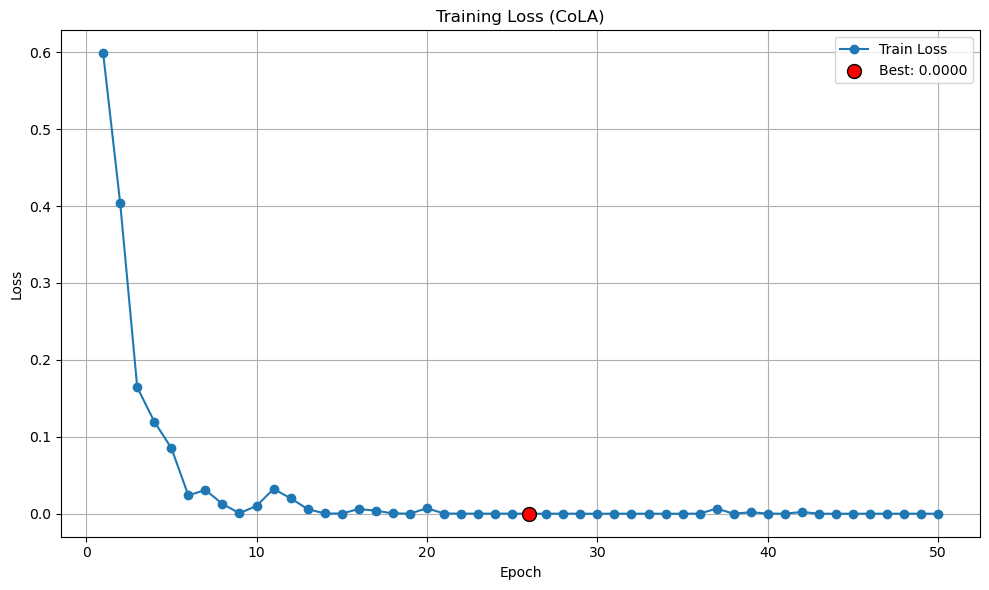

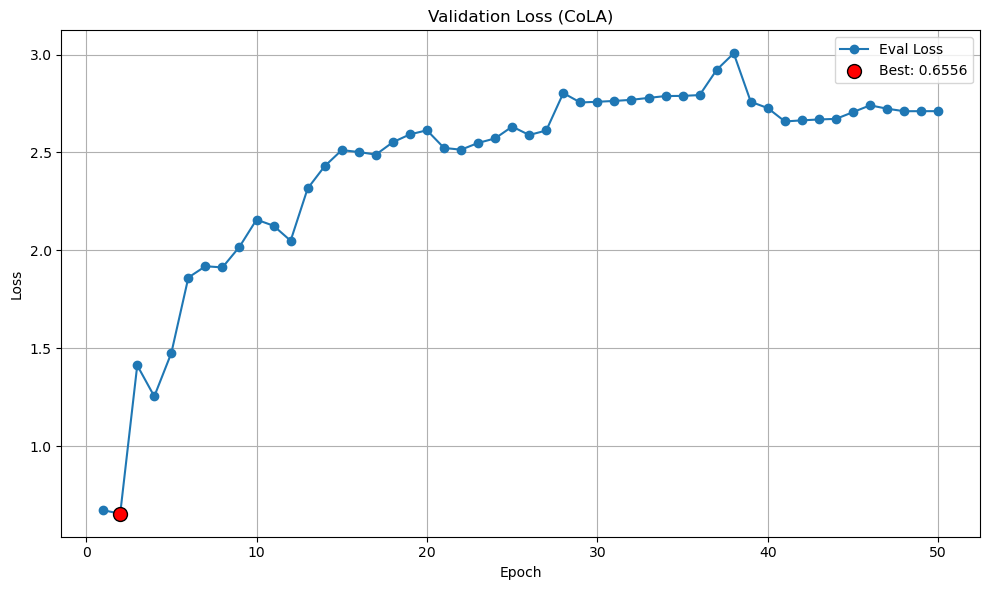

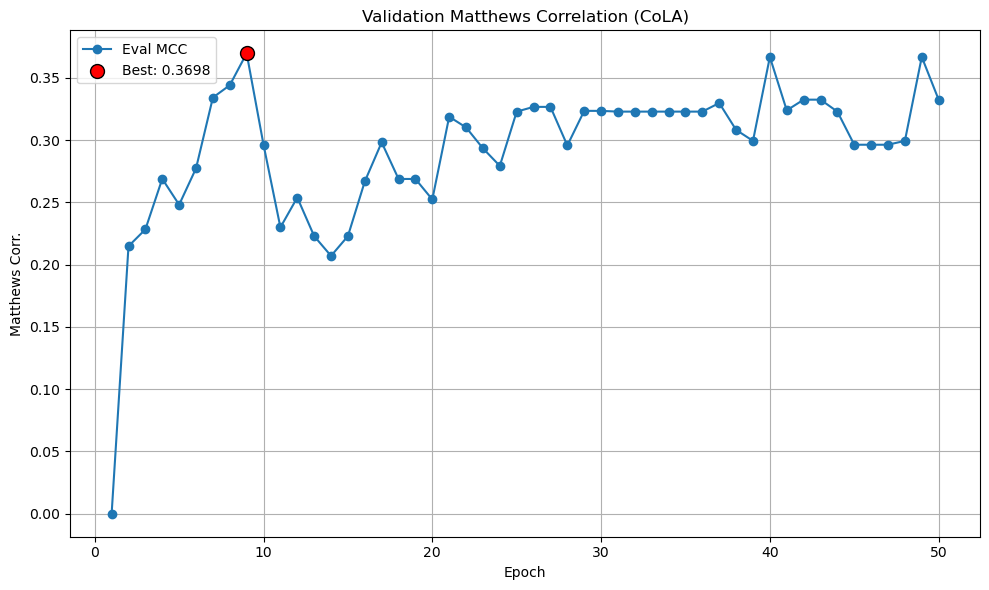

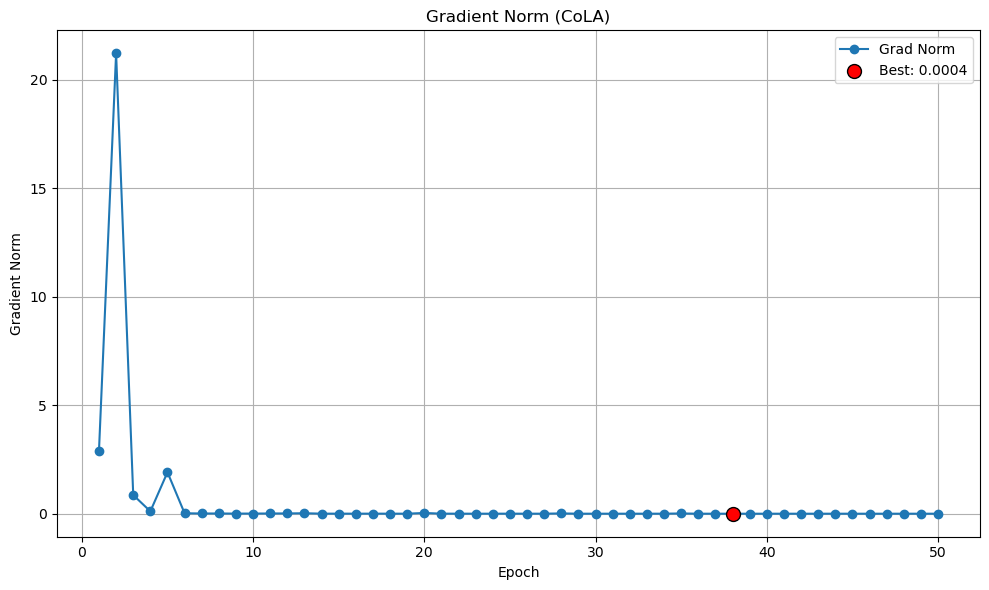

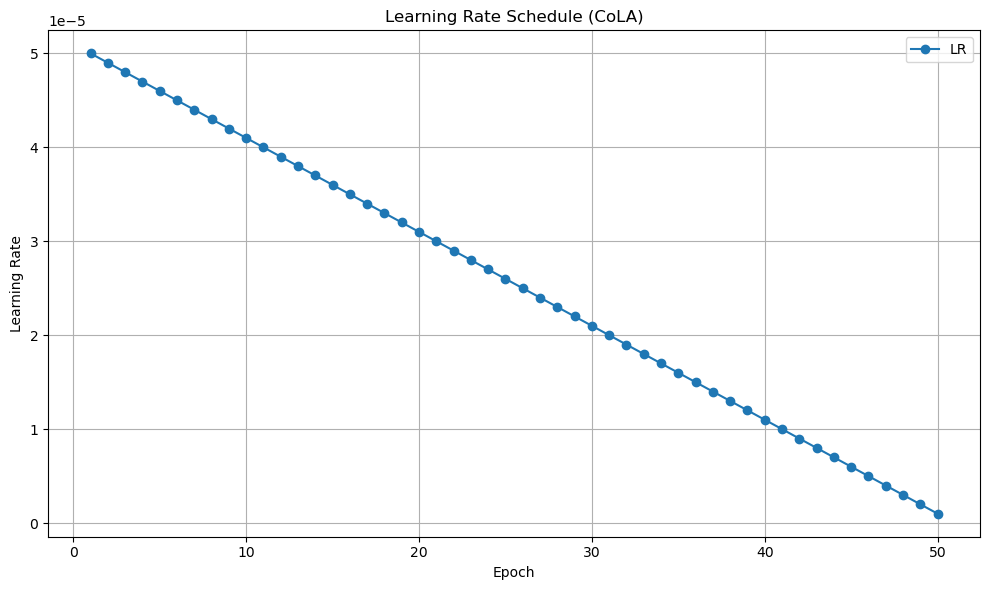

In [19]:
import matplotlib.pyplot as plt

# Hardcoded log values from your Cola training run, Epochs 1–50
epochs = list(range(1, 51))

eval_matthews = [
    0.0, 0.2149, 0.2284, 0.2690, 0.2482, 0.2774, 0.3343, 0.3442, 0.3698, 0.2964,
    0.2300, 0.2540, 0.2230, 0.2071, 0.2230, 0.2669, 0.2983, 0.2689, 0.2689, 0.2524,
    0.3189, 0.3103, 0.2935, 0.2794, 0.3230, 0.3268, 0.3268, 0.2958, 0.3236, 0.3236,
    0.3230, 0.3230, 0.3230, 0.3230, 0.3230, 0.3230, 0.3299, 0.3083, 0.2995, 0.3669,
    0.3240, 0.3326, 0.3326, 0.3230, 0.2964, 0.2964, 0.2964, 0.2995, 0.3669, 0.3326
]

eval_loss = [
    0.6735, 0.6556, 1.4130, 1.2546, 1.4760, 1.8615, 1.9191, 1.9131, 2.0184, 2.1571,
    2.1258, 2.0494, 2.3163, 2.4302, 2.5120, 2.5024, 2.4890, 2.5525, 2.5924, 2.6133,
    2.5232, 2.5142, 2.5486, 2.5719, 2.6321, 2.5892, 2.6123, 2.8032, 2.7552, 2.7589,
    2.7631, 2.7689, 2.7786, 2.7881, 2.7889, 2.7930, 2.9220, 3.0061, 2.7589, 2.7265,
    2.6585, 2.6639, 2.6686, 2.6715, 2.7060, 2.7407, 2.7235, 2.7106, 2.7109, 2.7109
]

train_loss = [
    0.5985, 0.4036, 0.1643, 0.1197, 0.0854, 0.0238, 0.0309, 0.0127, 0.0006, 0.0102,
    0.0322, 0.0201, 0.0060, 0.0003, 0.0002, 0.0061, 0.0039, 0.0004, 0.0001, 0.0071,
    0.0002, 0.0001, 0.0001, 0.0001, 0.0001, 0.0, 0.0, 0.0001, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0001, 0.0067, 0.0, 0.002, 0.0001,
    0.0, 0.0023, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
]

grad_norm = [
    2.90, 21.21, 0.86, 0.11, 1.91, 0.02, 0.01, 0.01, 0.005, 0.007,
    0.010, 0.013, 0.021, 0.003, 0.003, 0.002, 0.003, 0.002, 0.002, 0.034,
    0.003, 0.0019, 0.0009, 0.0014, 0.0024, 0.0012, 0.0012, 0.013, 0.0011, 0.0011,
    0.0011, 0.0011, 0.0012, 0.0011, 0.0114, 0.0005, 0.0005, 0.0004, 0.0004, 0.0004,
    0.0004, 0.0004, 0.0005, 0.0005, 0.0004, 0.0004, 0.0004, 0.0004, 0.0005, 0.0005
]

learning_rate = [round(5e-5 - i * (5e-5 / 50), 8) for i in range(50)]  # linear decay

# Plotting helper
def plot_metric(values, title, ylabel, filename, label, highlight_best=False, mode='min'):
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, values, marker='o', label=label)
    if highlight_best:
        if mode == 'min':
            best_idx = values.index(min(values))
            best_val = min(values)
        else:
            best_idx = values.index(max(values))
            best_val = max(values)
        plt.scatter(epochs[best_idx], best_val, color='red', s=100, edgecolors='black',
                    label=f'Best: {best_val:.4f}', zorder=5)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

# Generate plots
plot_metric(train_loss, "Training Loss (CoLA)", "Loss", "cola_train_loss.png", "Train Loss", highlight_best=True, mode="min")
plot_metric(eval_loss, "Validation Loss (CoLA)", "Loss", "cola_eval_loss.png", "Eval Loss", highlight_best=True, mode="min")
plot_metric(eval_matthews, "Validation Matthews Correlation (CoLA)", "Matthews Corr.", "cola_eval_matthews.png", "Eval MCC", highlight_best=True, mode="max")
plot_metric(grad_norm, "Gradient Norm (CoLA)", "Gradient Norm", "cola_grad_norm.png", "Grad Norm", highlight_best=True, mode="min")
plot_metric(learning_rate, "Learning Rate Schedule (CoLA)", "Learning Rate", "cola_learning_rate.png", "LR", highlight_best=False)
